In [1]:
import numpy as np
from collections import defaultdict
import gymnasium as gym

class BlackjackQLearningAgent:
    def __init__(self, learning_rate=0.1, discount_factor=0.95, epsilon=1.0, epsilon_decay=0.99999, min_epsilon=0.01):
        self.q_values = defaultdict(lambda: np.zeros(2))
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

    def get_action(self, state):
        if np.random.random() < self.epsilon:
            action = np.random.choice([0, 1])
        else:
            action = np.argmax(self.q_values[state])
        
        return action

    def update(self, state, action, reward, next_state, done):
        current_q = self.q_values[state][action]
        if done:
            target_q = reward
        else:
            target_q = reward + self.gamma * np.max(self.q_values[next_state])
        self.q_values[state][action] += self.lr * (target_q - current_q)

class BlackjackEnv(gym.Env):
    def __init__(self, render_mode=None, natural=False, sab=False, total_decks=5):
        self.action_space = gym.spaces.Discrete(2)
        self.observation_space = gym.spaces.Tuple(
            (gym.spaces.Discrete(32), gym.spaces.Discrete(11), gym.spaces.Discrete(2))
        )
        self.natural = natural
        self.sab = sab
        self.render_mode = render_mode
        self.running_count = 0
        self.betting_unit = 1
        self.money = 50
        self.current_bet = 1
        one_suite = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10]
        self.original_deck = one_suite * 4 * total_decks
        self.deck = self.original_deck.copy()

    def step(self, action):
        assert self.action_space.contains(action)
        if action:
            self.player.append(self.draw_card(self.np_random))
            if self.is_bust(self.player):
                terminated = True
                reward = -1.0
            else:
                terminated = False
                reward = 0.0
        else:
            terminated = True
            while self.sum_hand(self.dealer) < 17:
                self.dealer.append(self.draw_card(self.np_random))
            reward = self.cmp(self.score(self.player), self.score(self.dealer))
            if self.sab and self.is_natural(self.player) and not self.is_natural(self.dealer):
                reward = 1.0
            elif not self.sab and self.natural and self.is_natural(self.player) and reward == 1.0:
                reward = 1.5

        self.money += reward * self.current_bet
        return self._get_obs(), reward, terminated, self.money

    def _get_obs(self):
        return (self.sum_hand(self.player), self.dealer[0], int(self.usable_ace(self.player)))


    def reset(self, seed=None):
        super().reset(seed=seed)
        self.money = 50
        self.deck = self.original_deck.copy()
        self.running_count = 0
        return self.new_round()

    def new_round(self):
        self.dealer = self.draw_hand(self.np_random)
        self.player = self.draw_hand(self.np_random)
        return self._get_obs()

    def draw_card(self, np_random):
        if len(self.deck) == 0:
            print("Deck is empty! Reshuffling...")
            self.deck = self.original_deck.copy()  # Reshuffle if empty
        card_index = np_random.choice(len(self.deck))
        card = self.deck[card_index]
        if card in [1, 10]:
            self.running_count -= 1
        elif 2 <= card <= 6:
            self.running_count += 1
        self.deck.pop(card_index)
        return card


    def draw_hand(self, np_random):
        return [self.draw_card(np_random), self.draw_card(np_random)]

    def getRemainingDecks(self):
        return round(len(self.deck) / 52 * 2) / 2

    @staticmethod
    def cmp(a, b):
        return float(a > b) - float(a < b)

    @staticmethod
    def usable_ace(hand):
        return 1 in hand and sum(hand) + 10 <= 21

    @staticmethod
    def sum_hand(hand):
        if BlackjackEnv.usable_ace(hand):
            return sum(hand) + 10
        return sum(hand)

    @staticmethod
    def is_bust(hand):
        return BlackjackEnv.sum_hand(hand) > 21

    @staticmethod
    def score(hand):
        return 0 if BlackjackEnv.is_bust(hand) else BlackjackEnv.sum_hand(hand)

    @staticmethod
    def is_natural(hand):
        return sorted(hand) == [1, 10]

# Original train_agent function
# def train_agent(env, agent, num_episodes):
#     for episode in range(num_episodes):
#         state = env.reset()
#         done = False
#         while not done:
#             action = agent.get_action(state)
#             next_state, reward, done, _ = env.step(action)
#             agent.update(state, action, reward, next_state, done)
#             state = next_state
            
#             if env.money < 1:
#                 done = True
        
#         # Decay epsilon after each episode
#         agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)
        
#         if episode % 1000 == 0:
#             print(f"Episode {episode} completed, Epsilon: {agent.epsilon:.4f}")

# Modify train_agent to record money over rounds
def train_agent(env, agent, num_episodes):
    money_over_time = []
    for episode in range(num_episodes):
        state = env.reset()
        done = False
        while not done:
            action = agent.get_action(state)
            next_state, reward, done, _ = env.step(action)
            agent.update(state, action, reward, next_state, done)
            state = next_state
            
            if env.money < 1:
                done = True
        
        # Record money after each episode
        money_over_time.append(env.money)
        
        # Decay epsilon after each episode
        agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)
        
        if episode % 1000 == 0:
            print(f"Episode {episode} completed, Epsilon: {agent.epsilon:.4f}")
    
    return money_over_time

# Original evaluate_agent function
# def evaluate_agent(env, agent, num_episodes=10000):
#     total_reward = 0
#     for episode in range(num_episodes):
#         state = env.reset()
#         done = False
#         episode_reward = 0
#         while not done:
#             action = np.argmax(agent.q_values[state])  # Use greedy action
#             state, reward, done, _ = env.step(action)
#             episode_reward += reward
#         total_reward += episode_reward
        
#         if env.money < 1:
#             break
    
#     return total_reward / (episode + 1)  # Average reward per episode

# Modify evaluate_agent to record money over rounds
def evaluate_agent(env, agent, num_episodes=10000):
    money_over_time = []
    total_reward = 0
    for episode in range(num_episodes):
        state = env.reset()
        done = False
        episode_reward = 0
        while not done:
            action = np.argmax(agent.q_values[state])  # Use greedy action
            state, reward, done, _ = env.step(action)
            episode_reward += reward
        
        total_reward += episode_reward
        money_over_time.append(env.money)
        
        if env.money < 1:
            break
    
    return total_reward / (episode + 1), money_over_time  # Average reward per episode


In [2]:
# Create environment and agent
env = BlackjackEnv()
agent = BlackjackQLearningAgent()

Episode 0 completed, Epsilon: 0.2466
Episode 1000 completed, Epsilon: 0.2441
Episode 2000 completed, Epsilon: 0.2417
Episode 3000 completed, Epsilon: 0.2393
Episode 4000 completed, Epsilon: 0.2369
Episode 5000 completed, Epsilon: 0.2346
Episode 6000 completed, Epsilon: 0.2322
Episode 7000 completed, Epsilon: 0.2299
Episode 8000 completed, Epsilon: 0.2276
Episode 9000 completed, Epsilon: 0.2254
Average reward over 10,000 episodes: -0.0594


NameError: name 'most_loss' is not defined

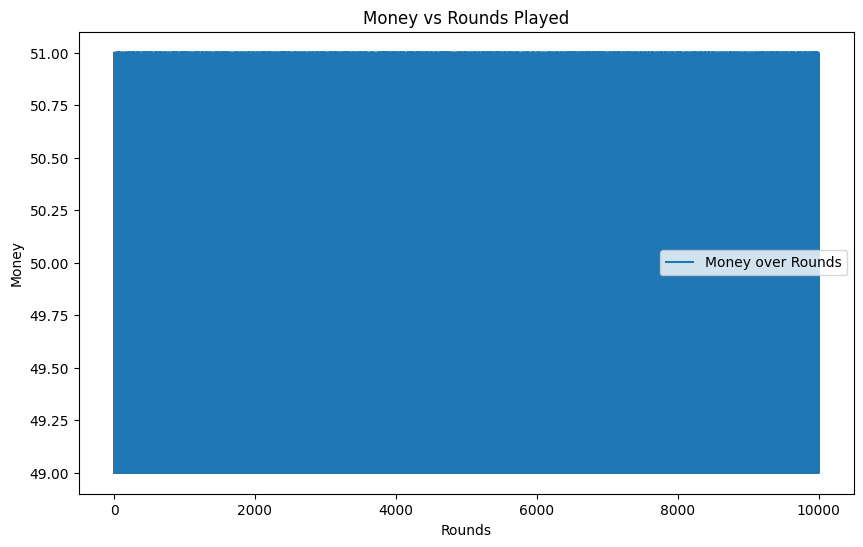

In [8]:
import matplotlib.pyplot as plt

# Train the agent and record money over time
money_over_time_train = train_agent(env, agent, num_episodes=10000)

# Evaluate the agent and record money over time
average_reward, money_over_time_eval = evaluate_agent(env, agent)
print(f"Average reward over 10,000 episodes: {average_reward}")


# Plot configuration
# plt.figure(figsize=(12, 6))

# # Line graph for training and evaluation
# plt.plot(money_over_time_train, linestyle='-', marker='', color='b', label='Training')
# plt.plot(money_over_time_eval, linestyle='-', marker='', color='r', label='Evaluation')

# # Axis labels and title
# plt.xlabel('Episodes', fontsize=14)
# plt.ylabel('Money', fontsize=14)
# plt.title('Money Over Episodes (Training vs. Evaluation)', fontsize=16)

# # Adding legend and grid for clarity
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.1)

# # Display the plot
# plt.show()

# Plot the graph
plt.figure(figsize=(10, 6))
plt.plot(range(len(money_over_time_eval)), money_over_time_eval, label='Money over Rounds')
plt.xlabel('Rounds')
plt.ylabel('Money')
plt.title('Money vs Rounds Played')
plt.legend()

# Add statistics box
stats_text = f'Most Loss: {most_loss}\nMost Profit: {most_profit}\nMedian Profit: {median_profit}\nStd Dev: {std_dev}'
plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.savefig('money_vs_rounds_Q_Perplex.png', bbox_inches='tight')
plt.show()

# Plot the graph of money vs decks remaining
decks_remaining = [env.getRemainingDecks() for _ in range(rounds)]
plt.figure(figsize=(10, 6))
plt.plot(decks_remaining, money_history, label='Money over Decks Remaining')
plt.xlabel('Decks Remaining')
plt.ylabel('Money')
plt.title('Money vs Decks Remaining')
plt.legend()

# Save the plot
plt.savefig('money_vs_decks_remaining_QL_Perplex.png', bbox_inches='tight')
plt.show()


